# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [11]:
import numpy as np
import pandas as pd

In [12]:
np.random.seed(42)

up = np.random.normal(loc=1, scale=1, size=500)
down = np.random.normal(loc=-1, scale=1, size=500)

expressao_genica = np.concatenate([up, down])


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [13]:
genes_diff = np.random.randint(-100, 100, size=1000)

df_ex2aula14 = pd.DataFrame({
    'expressao_genica': expressao_genica,
    'genes_diff': genes_diff
})

df_ex2aula14

,expressao_genica,genes_diff
0,1.496714,18
1,0.861736,71
2,1.647689,-52
3,2.523030,3
4,0.765847,-40
...,...,...
995,-1.281100,-46
996,0.797687,31
997,-0.359157,19
998,-1.571179,-77


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: A categorização foi baseada na criação de um índice combinado que integra as duas variáveis (expressao_genica e genes_diff) em uma única medida.  Como as variáveis estão em escalas diferentes (uma contínua em torno de -3 a 3 e outra discreta podendo variar de -100 a 100), foi necessário ajustar a escala de genes_diff. Esse ajuste foi feito dividindo seus valores por 50, o que reduz sua magnitude e evita que essa variável tenha peso desproporcional no cálculo do índice. Assim, ambas passam a contribuir de forma mais equilibrada. Após esse ajuste, foi calculada a média entre as duas variáveis, gerando um índice único que representa simultaneamente a direção (valores positivos ou negativos) e a intensidade da variação. Valores negativos indicam predominância de downregulation, enquanto valores positivos indicam upregulation. A partir desse índice, os dados foram divididos em seis grupos utilizando pontos de corte (-2, -1, 0, 1 e 2). Esses limites foram escolhidos com base na lógica de distância em relação ao zero: valores próximos de zero representam alterações leves, enquanto valores mais distantes indicam alterações moderadas ou fortes. Dessa forma, cada grupo combina duas dimensões importantes: o sentido da regulação (up ou down) e a magnitude da mudança. Essa abordagem permite reduzir a complexidade dos dados, sintetizando duas variáveis em uma classificação única, sem perder a capacidade de distinguir diferentes níveis de intensidade, tornando a análise mais interpretável tanto do ponto de vista estatístico quanto biológico.


In [14]:
def categorizar_conjunto(expr, genes):
    
    # ajuste simples de escala
    indice = (expr + (genes / 50)) / 2
    
    if indice < -2:
        return "Down forte"
    elif indice < -1:
        return "Down moderado"
    elif indice < 0:
        return "Down leve"
    elif indice < 1:
        return "Up leve"
    elif indice < 2:
        return "Up moderado"
    else:
        return "Up forte"

df_ex2aula14['grupo_conjunto'] = df_ex2aula14.apply(
    lambda row: categorizar_conjunto(row['expressao_genica'], row['genes_diff']),
    axis=1
)

df_ex2aula14

,expressao_genica,genes_diff,grupo_conjunto
0,1.496714,18,Up leve
1,0.861736,71,Up moderado
2,1.647689,-52,Up leve
3,2.523030,3,Up moderado
4,0.765847,-40,Down leve
...,...,...,...
995,-1.281100,-46,Down moderado
996,0.797687,31,Up leve
997,-0.359157,19,Up leve
998,-1.571179,-77,Down moderado


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [17]:
def tabela_frequencia(serie):
    freq_abs = serie.value_counts()
    freq_rel = serie.value_counts(normalize=True)
    freq_acum = freq_abs.cumsum()
    
    df_freq = pd.DataFrame({
        'Frequência Absoluta': freq_abs,
        'Frequência Relativa': freq_rel,
        'Frequência Acumulada': freq_acum
    })
    
    return df_freq

In [19]:
tabela_conjunto = pd.DataFrame({
    'Frequencia_Absoluta': df_ex2aula14['grupo_conjunto'].value_counts().sort_index(),
    'Frequencia_Relativa': df_ex2aula14['grupo_conjunto'].value_counts(normalize=True).sort_index(),
})

tabela_conjunto['Frequencia_Acumulada'] = tabela_conjunto['Frequencia_Absoluta'].cumsum()

tabela_conjunto

,Frequencia_Absoluta,Frequencia_Relativa,Frequencia_Acumulada
grupo_conjunto,,,
Down forte,11,0.011,11
Down leve,369,0.369,380
Down moderado,126,0.126,506
Up forte,8,0.008,514
Up leve,337,0.337,851
Up moderado,149,0.149,1000


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

In [28]:
import matplotlib.pyplot as plt

def categorizar_expr_label(valor):
    if valor < -2:
        return "Down forte"
    elif valor < -1:
        return "Down moderado"
    elif valor < 0:
        return "Down leve"
    elif valor < 1:
        return "Up leve"
    elif valor < 2:
        return "Up moderado"
    else:
        return "Up forte"
    
def categorizar_genes_label(valor):
    if valor < -50:
        return "Down forte"
    elif valor < -20:
        return "Down moderado"
    elif valor < 0:
        return "Down leve"
    elif valor < 20:
        return "Up leve"
    elif valor < 50:
        return "Up moderado"
    else:
        return "Up forte"

In [29]:
df_ex2aula14['grupo_expr'] = df_ex2aula14['expressao_genica'].apply(categorizar_expr_label)
df_ex2aula14['grupo_genes'] = df_ex2aula14['genes_diff'].apply(categorizar_genes_label)

### Expressão

(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.]),
 [Text(-1.0, 0, 'Up moderado'),
  Text(0.0, 0, 'Down forte'),
  Text(1.0, 0, 'Down leve'),
  Text(2.0, 0, 'Down moderado'),
  Text(3.0, 0, 'Up forte'),
  Text(4.0, 0, 'Up leve'),
  Text(5.0, 0, 'Up moderado'),
  Text(6.0, 0, '')])

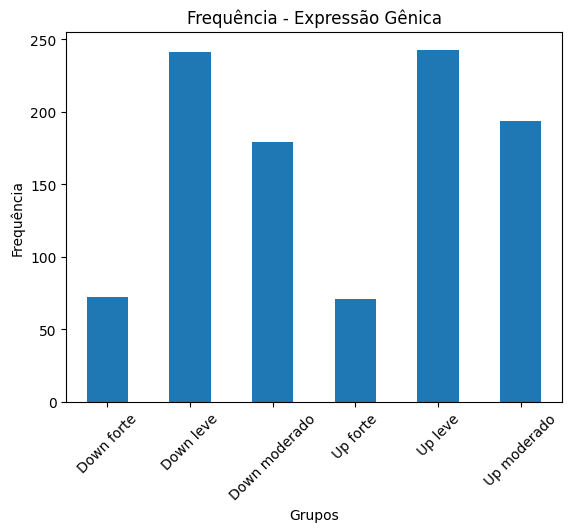

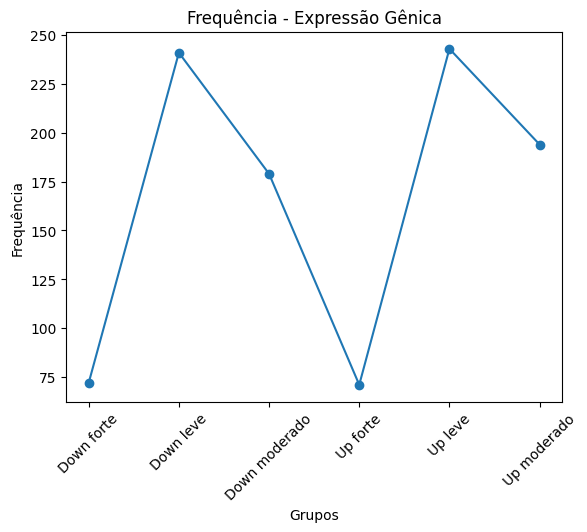

In [30]:
freq_expr = df_ex2aula14['grupo_expr'].value_counts().sort_index()

plt.figure()
freq_expr.plot(kind='bar')
plt.title('Frequência - Expressão Gênica')
plt.xlabel('Grupos')
plt.ylabel('Frequência')
plt.xticks(rotation=45)

plt.figure()
freq_expr.plot(kind='line', marker='o')
plt.title('Frequência - Expressão Gênica')
plt.xlabel('Grupos')
plt.ylabel('Frequência')
plt.xticks(rotation=45)

### Número

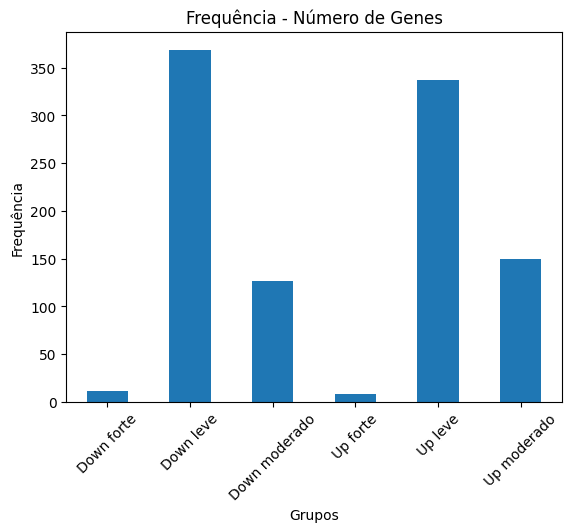

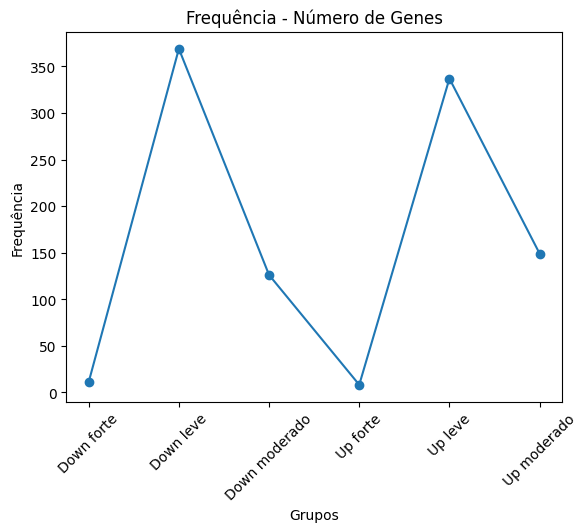

In [23]:
freq_genes = df_ex2aula14['grupo_conjunto'].value_counts().sort_index()

# Barras
plt.figure()
freq_genes.plot(kind='bar')
plt.title('Frequência - Número de Genes')
plt.xlabel('Grupos')
plt.ylabel('Frequência')
plt.xticks(rotation=45)

# Linhas
plt.figure()
freq_genes.plot(kind='line', marker='o')
plt.title('Frequência - Número de Genes')
plt.xlabel('Grupos')
plt.ylabel('Frequência')
plt.xticks(rotation=45)

plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

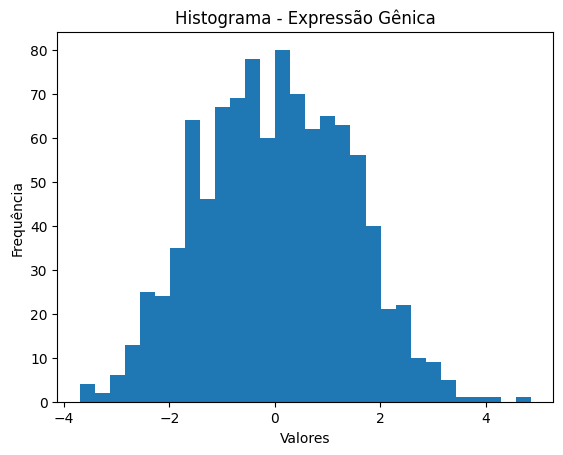

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_ex2aula14['expressao_genica'], bins=30)
plt.title('Histograma - Expressão Gênica')
plt.xlabel('Valores')
plt.ylabel('Frequência')

plt.show()

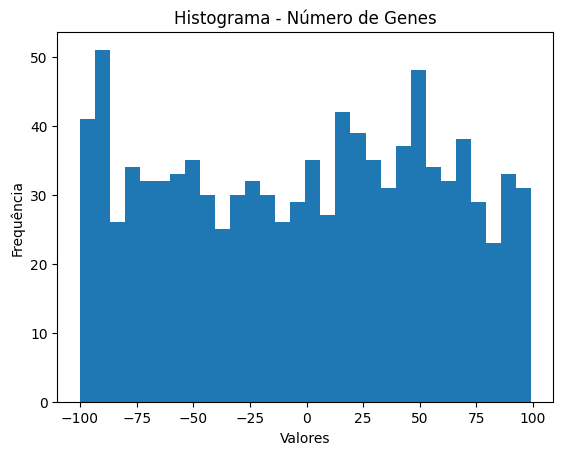

In [32]:
plt.figure()
plt.hist(df_ex2aula14['genes_diff'], bins=30)
plt.title('Histograma - Número de Genes')
plt.xlabel('Valores')
plt.ylabel('Frequência')

plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

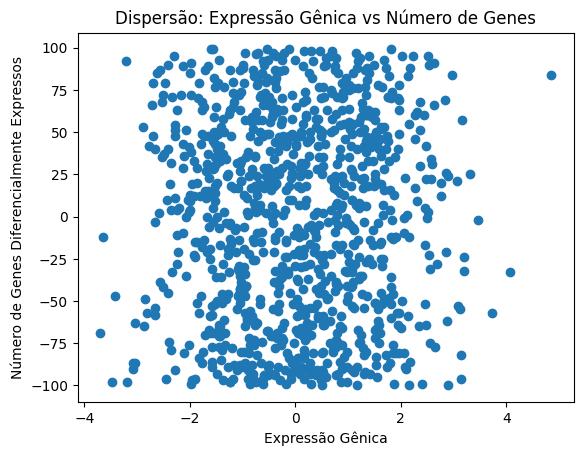

In [33]:
plt.figure()
plt.scatter(df_ex2aula14['expressao_genica'], df_ex2aula14['genes_diff'])

plt.title('Dispersão: Expressão Gênica vs Número de Genes')
plt.xlabel('Expressão Gênica')
plt.ylabel('Número de Genes Diferencialmente Expressos')

plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

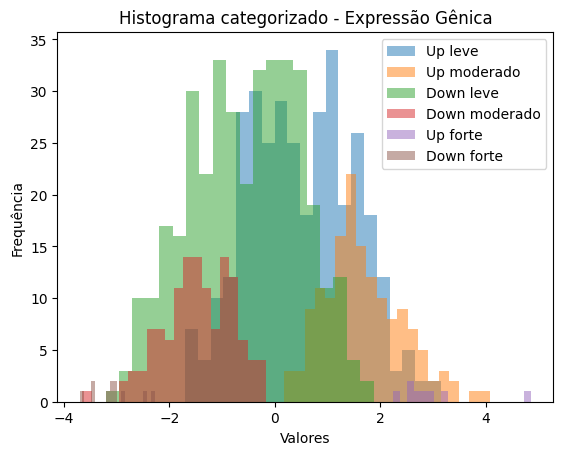

In [34]:
plt.figure()

for grupo in df_ex2aula14['grupo_conjunto'].unique():
    subset = df_ex2aula14[df_ex2aula14['grupo_conjunto'] == grupo]
    plt.hist(subset['expressao_genica'], bins=20, alpha=0.5, label=grupo)

plt.title('Histograma categorizado - Expressão Gênica')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend()
plt.show()

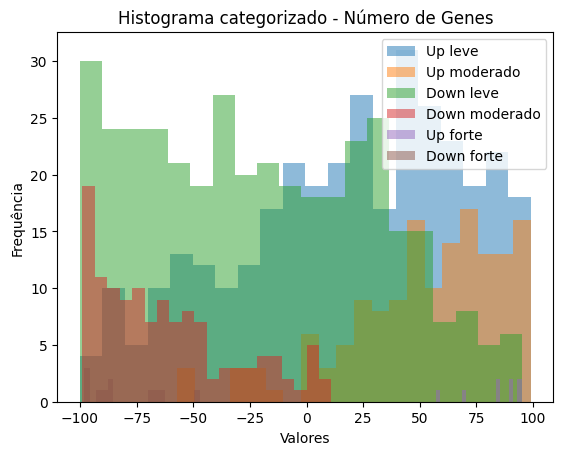

In [35]:
plt.figure()

for grupo in df_ex2aula14['grupo_conjunto'].unique():
    subset = df_ex2aula14[df_ex2aula14['grupo_conjunto'] == grupo]
    plt.hist(subset['genes_diff'], bins=20, alpha=0.5, label=grupo)

plt.title('Histograma categorizado - Número de Genes')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

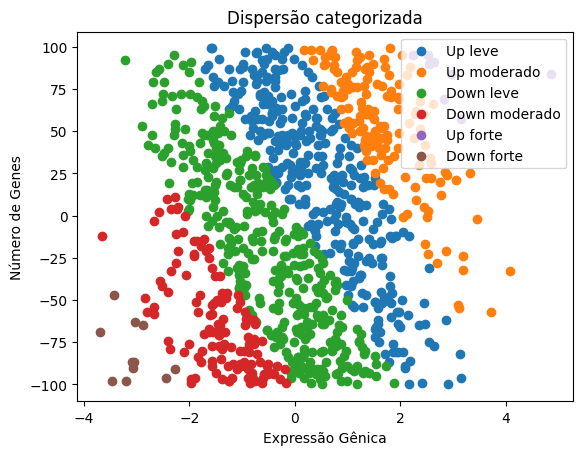

In [36]:
plt.figure()

for grupo in df_ex2aula14['grupo_conjunto'].unique():
    subset = df_ex2aula14[df_ex2aula14['grupo_conjunto'] == grupo]
    
    plt.scatter(
        subset['expressao_genica'],
        subset['genes_diff'],
        label=grupo
    )

plt.title('Dispersão categorizada')
plt.xlabel('Expressão Gênica')
plt.ylabel('Número de Genes')
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas| Discreta |
| % de células positivas| Contínua |
| Faixa de pH| Ordinal |
| Valor de pH| Contínua |
| mol/L| Contínua |
| UFC| Discreta |
| D.O.| Contínua |
| Grupo Sanguíneo| Nominal |
| Sorologia| Nominal |